In [1]:
import json
from collections import defaultdict
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
import torch
from typing import List
from sklearn.metrics import f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import re



In [2]:
output_dir = '/home/slim/dpo-rhlf-paraphrase-types/out/plots'
os.chdir('/home/slim/dpo-rhlf-paraphrase-types')

TOP_10_PARAPHRASE_TYPES = [
    "addition/deletion", "change of order", "derivational changes", "inflectional changes",
    "punctuation changes", "same polarity substitution (contextual)", "semantic based",
    "spelling changes", "subordination and nesting changes", "synthetic/analytic substitution"
]

textwidth2 = 3.08102 #twocolumn
textwidth1 = 6.30045 #onecolumn
aspect_ratio = (5 ** 0.5 - 1) / 2 # golden ratio
width1 = textwidth1
height1 = width1 * aspect_ratio
width2 = textwidth2
height2 = width2 * aspect_ratio
textwidthcm=15.99773 #onecolumn
textwidthcm=7.82315 #twocolumn
textheightcm=textwidthcm / aspect_ratio

# Results
## Effectiveness of DPO and RHLF in Paraphrase Generation

In [3]:
# Load the JSON data
with open('/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json', 'r') as file:
    data = json.load(file)

# Dictionary to store counts for each model
model_results = defaultdict(lambda: {'yes': 0, 'total': 0})

# Iterate through each entry in the JSON data
for entry in data:
    kind = entry['data']['Kind']
    # Check the "APT" choice value in the annotations
    for annotation in entry['annotations']:
        for result in annotation['result']:
            if result['from_name'] == "APT":
                choice = result['value']['choices'][0]
                model_results[kind]['total'] += 1
                if choice == "Yes":
                    model_results[kind]['yes'] += 1

# Calculate accuracy for each model
apt_percentages = {model: (counts['yes'] / counts['total']) * 100
                  for model, counts in model_results.items()}


print(apt_percentages)


{'base_model': 12.376237623762377, 'etpc_model': 11.76470588235294, 'dpo_model': 35.26315789473684}


In [4]:
# Dictionary to store counts for each (model, APT) pair
results = defaultdict(lambda: {'yes': 0, 'total': 0})

# Iterate through each entry in the JSON data
for entry in data:
    # Ensure entry is a dictionary before processing
    if isinstance(entry, dict):
        kind = entry.get('data', {}).get('Kind')
        apt_value = entry.get('data', {}).get('APT')
        
        # Proceed only if both kind and apt_value are found
        if kind and apt_value:
            annotations = entry.get('annotations', [])
            
            # Check if there are annotations
            if annotations:
                for annotation in annotations:
                    results_found = annotation.get('result', [])
                    
                    # Iterate through each result within the annotation
                    for result in results_found:
                        from_name = result.get('from_name')
                        
                        # Focus on results where from_name is "APT"
                        if from_name == "APT":
                            choice = result.get('value', {}).get('choices', [None])[0]
                            
                            # Check if the choice is valid
                            if choice:
                                results[(kind, apt_value)]['total'] += 1
                                if choice == "Yes":
                                    results[(kind, apt_value)]['yes'] += 1

# Calculate accuracy for each (model, APT) pair
apt_percentages = {
    (model, apt): (counts['yes'] / counts['total']) * 100
    for (model, apt), counts in results.items()
    if counts['total'] > 0  # Avoid division by zero
}

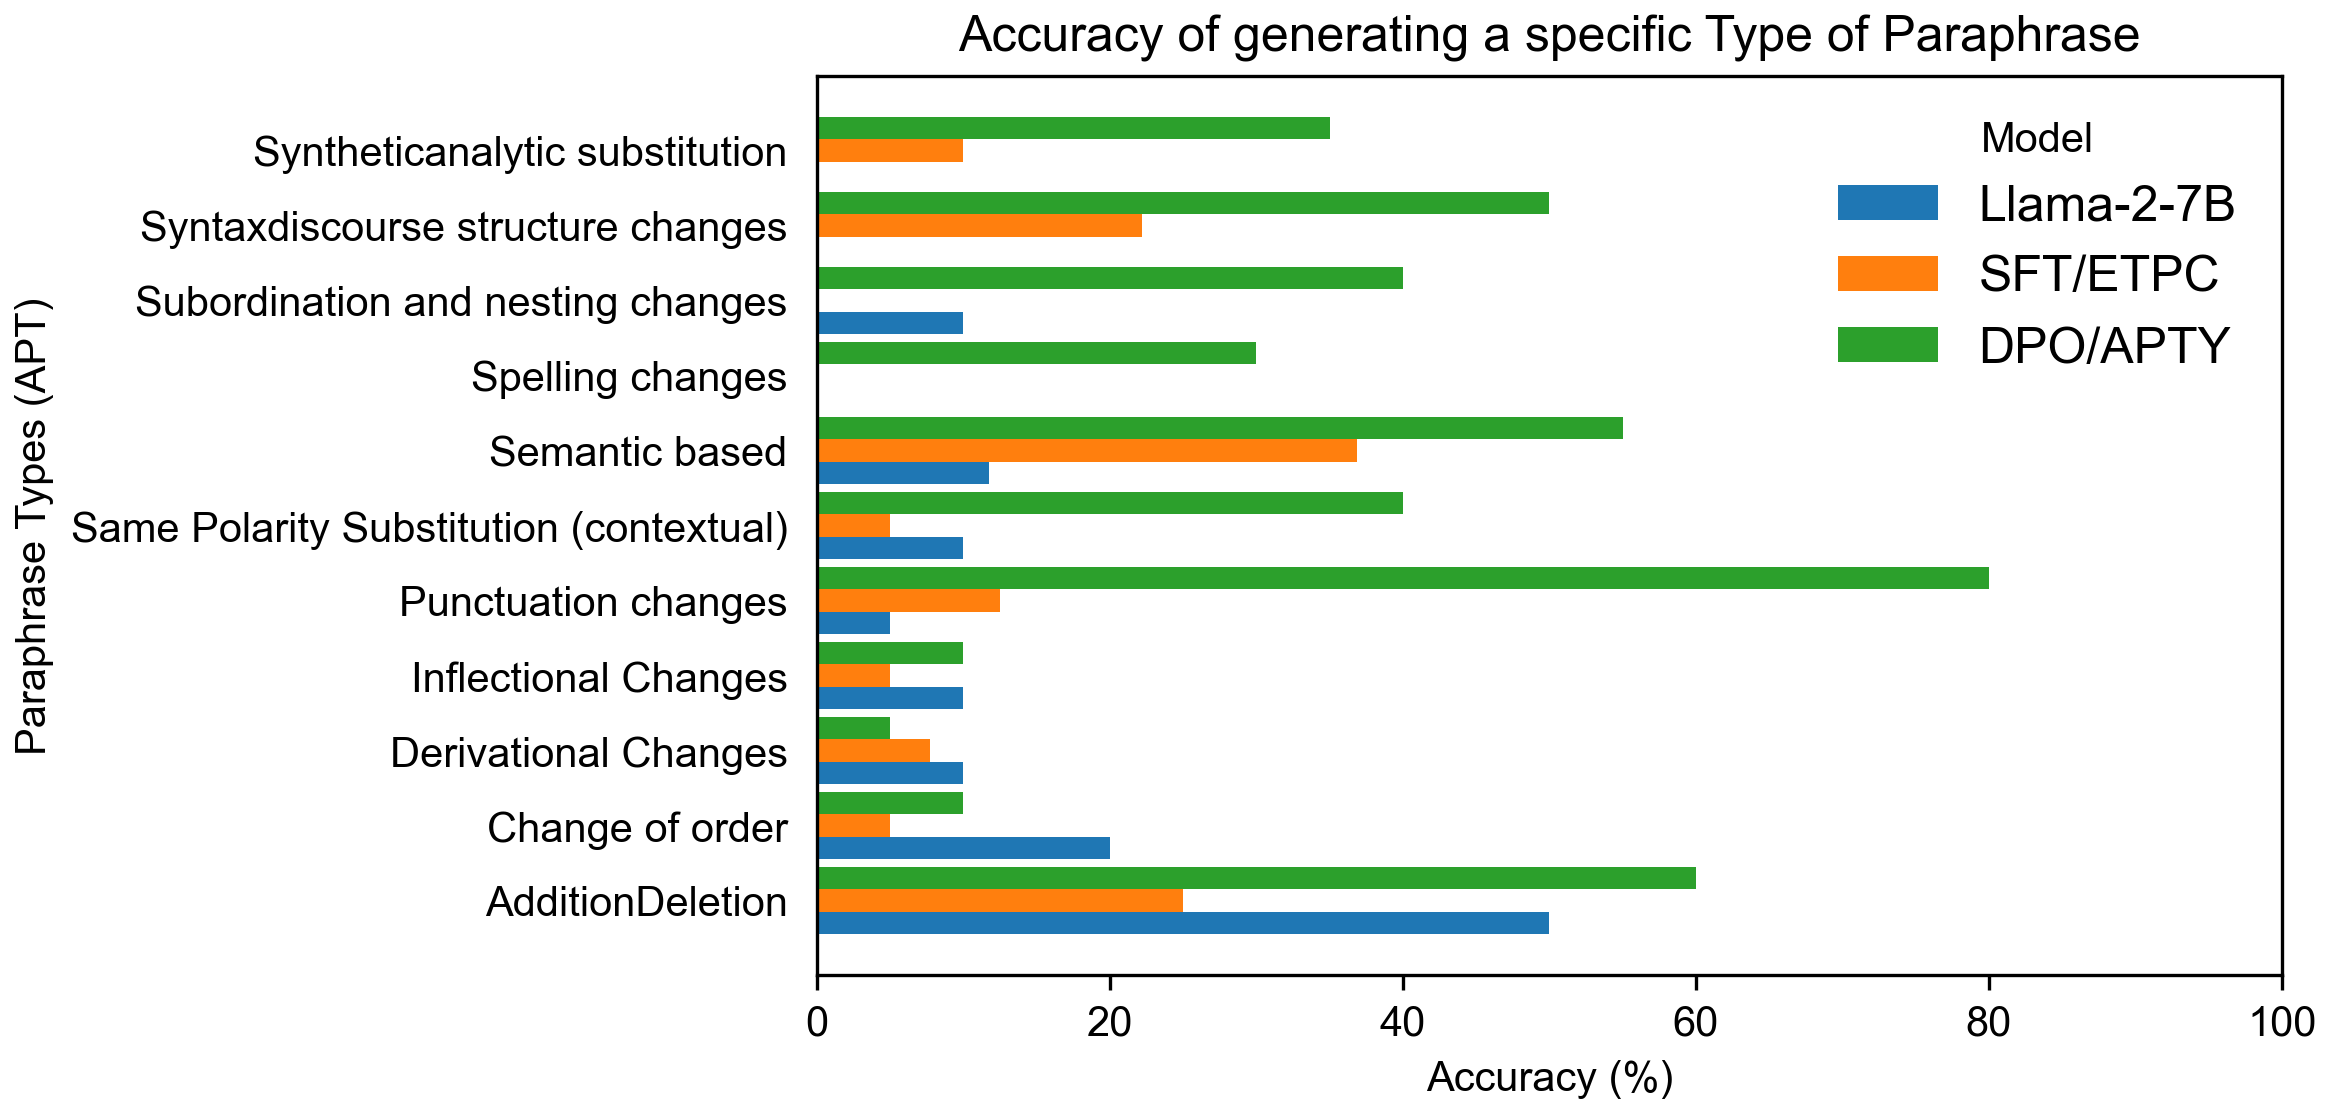

In [5]:
# Create a set of unique APT values and models in the specified order
apt_values = sorted(set(apt for _, apt in apt_percentages.keys()))
models = ["base_model", "etpc_model", "dpo_model"]  # Ordered list of models
model_labels = {
    "base_model": "Llama-2-7B",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY"
}

# Create data for plotting
y = np.arange(len(apt_values))  # the label locations for the y-axis
width = 0.3  # the width of the bars

# Create a dictionary to hold accuracy values for each model across APTs
model_accuracies = {
    model: [apt_percentages.get((model, apt), 0) for apt in apt_values]
    for model in models
}

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Plot each model's accuracy as a separate set of horizontal bars
for i, model in enumerate(models):
    plt.barh(y + i * width, model_accuracies[model], height=width, label=model_labels[model])

# Add labels and title
plt.ylabel('Paraphrase Types (APT)')
plt.xlabel('Accuracy (%)')
plt.title('Accuracy of generating a specific Type of Paraphrase', fontsize=12)
plt.yticks(y + width * (len(models) - 1) / 2, apt_values, fontsize=10)
plt.xlim(0, 100)  # Set x-axis limit to 100% for consistency
plt.legend(title='Model', fontsize=12)

ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis

output_path = os.path.join(output_dir, "llama_type_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Display the plot
plt.show()


## Incorporating Human-Ranked Data for Improved Paraphrase Generation

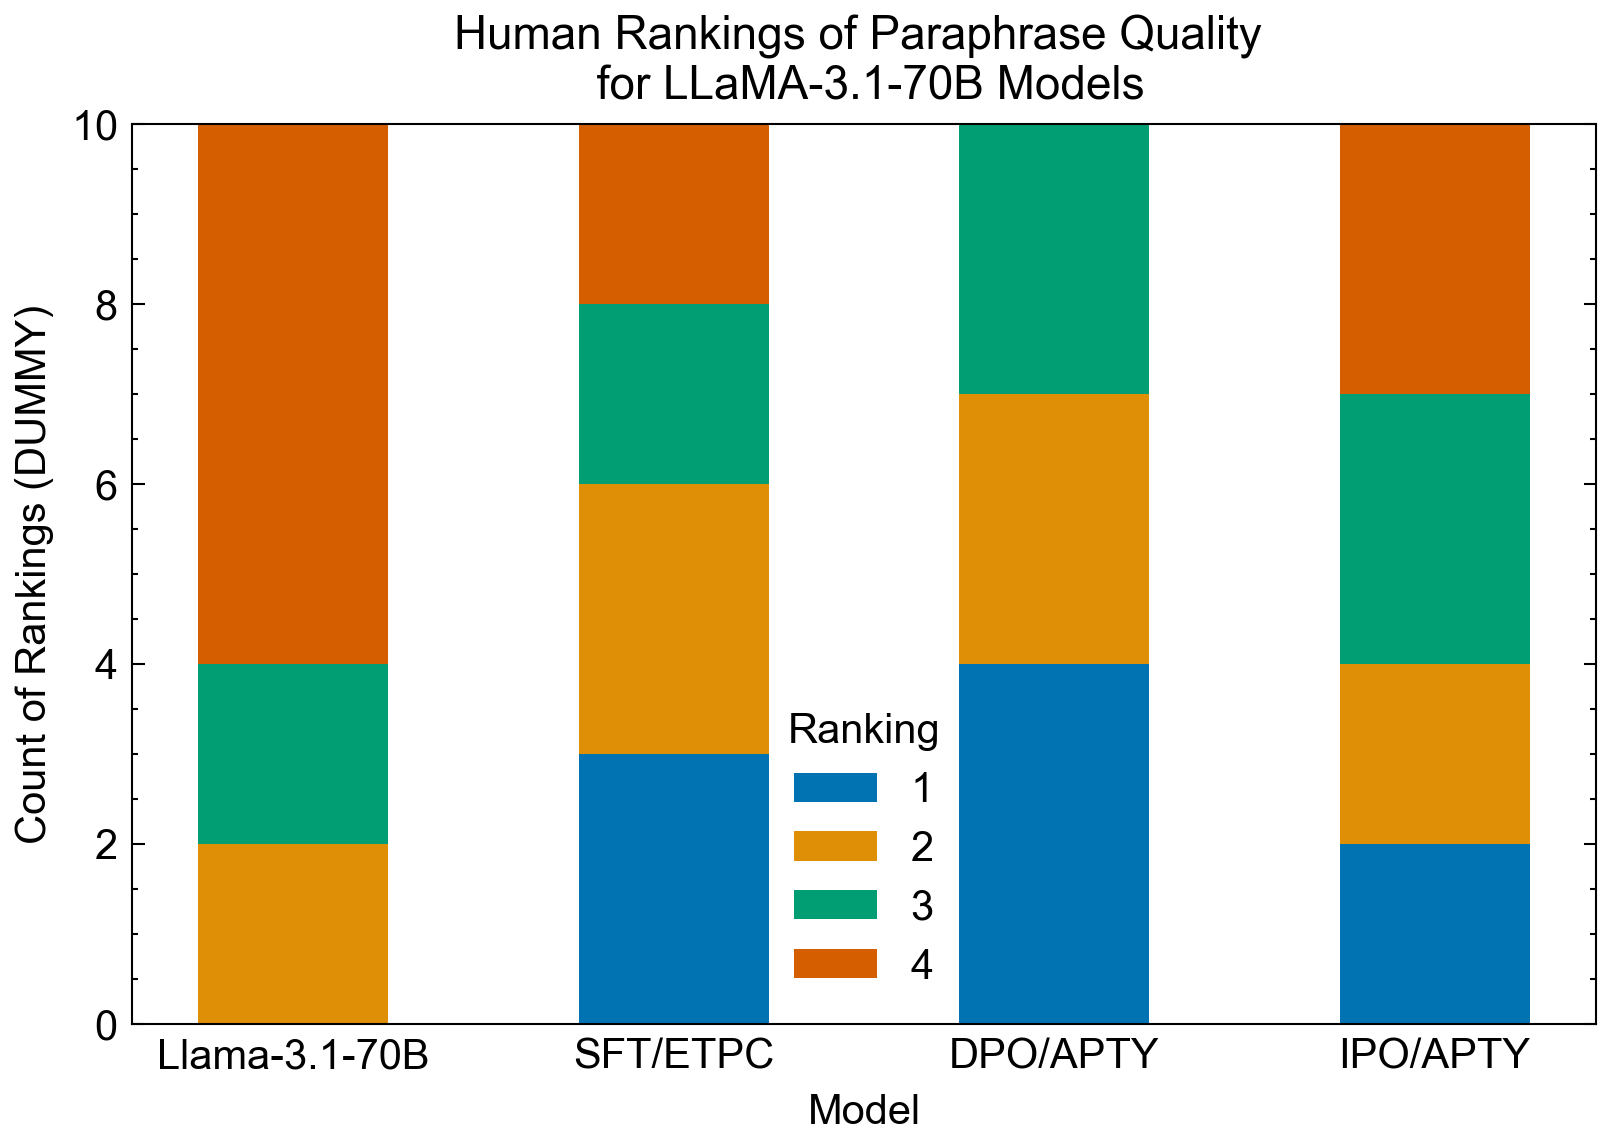

In [6]:
# Adding the base model rankings to the dummy data
data_with_base = {
    "Llama-3.1-70B": [4, 4, 4, 2, 4, 4, 3, 4, 2, 3],
    "SFT/ETPC": [1, 2, 3, 1, 2, 3, 4, 2, 1, 4],
    "DPO/APTY": [2, 1, 1, 3, 3, 2, 2, 1, 3, 1],
    "IPO/APTY": [3, 3, 2, 4, 1, 4, 1, 3, 4, 2]
}

# Convert updated data to a DataFrame
df_with_base = pd.DataFrame(data_with_base)

# Count how often each model got each ranking (1 to 4)
rank_counts_with_base = df_with_base.apply(lambda col: col.value_counts()).fillna(0).astype(int)

# Transpose for better plotting (stacked bar chart)
rank_counts_with_base = rank_counts_with_base.transpose()

# Plot the stacked bar chart with the base model
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

index = range(len(rank_counts_with_base))

for i, col in enumerate(rank_counts_with_base.columns):
    ax.bar(index, rank_counts_with_base[col], 0.5, bottom=rank_counts_with_base.iloc[:, :i].sum(axis=1))

# Set x-tick labels to the model names
ax.set_xticks(index)
ax.set_xticklabels(rank_counts_with_base.index, fontsize=10)


# Add labels and title
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('Count of Rankings (DUMMY)', fontsize=10)
ax.set_title('Human Rankings of Paraphrase Quality \n for LLaMA-3.1-70B Models', fontsize=11)


# Add legend
ax.legend(rank_counts_with_base.columns, title="Ranking", frameon=False, fontsize=10)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

## Broader NLP Task Improvements with Human-Ranked Data

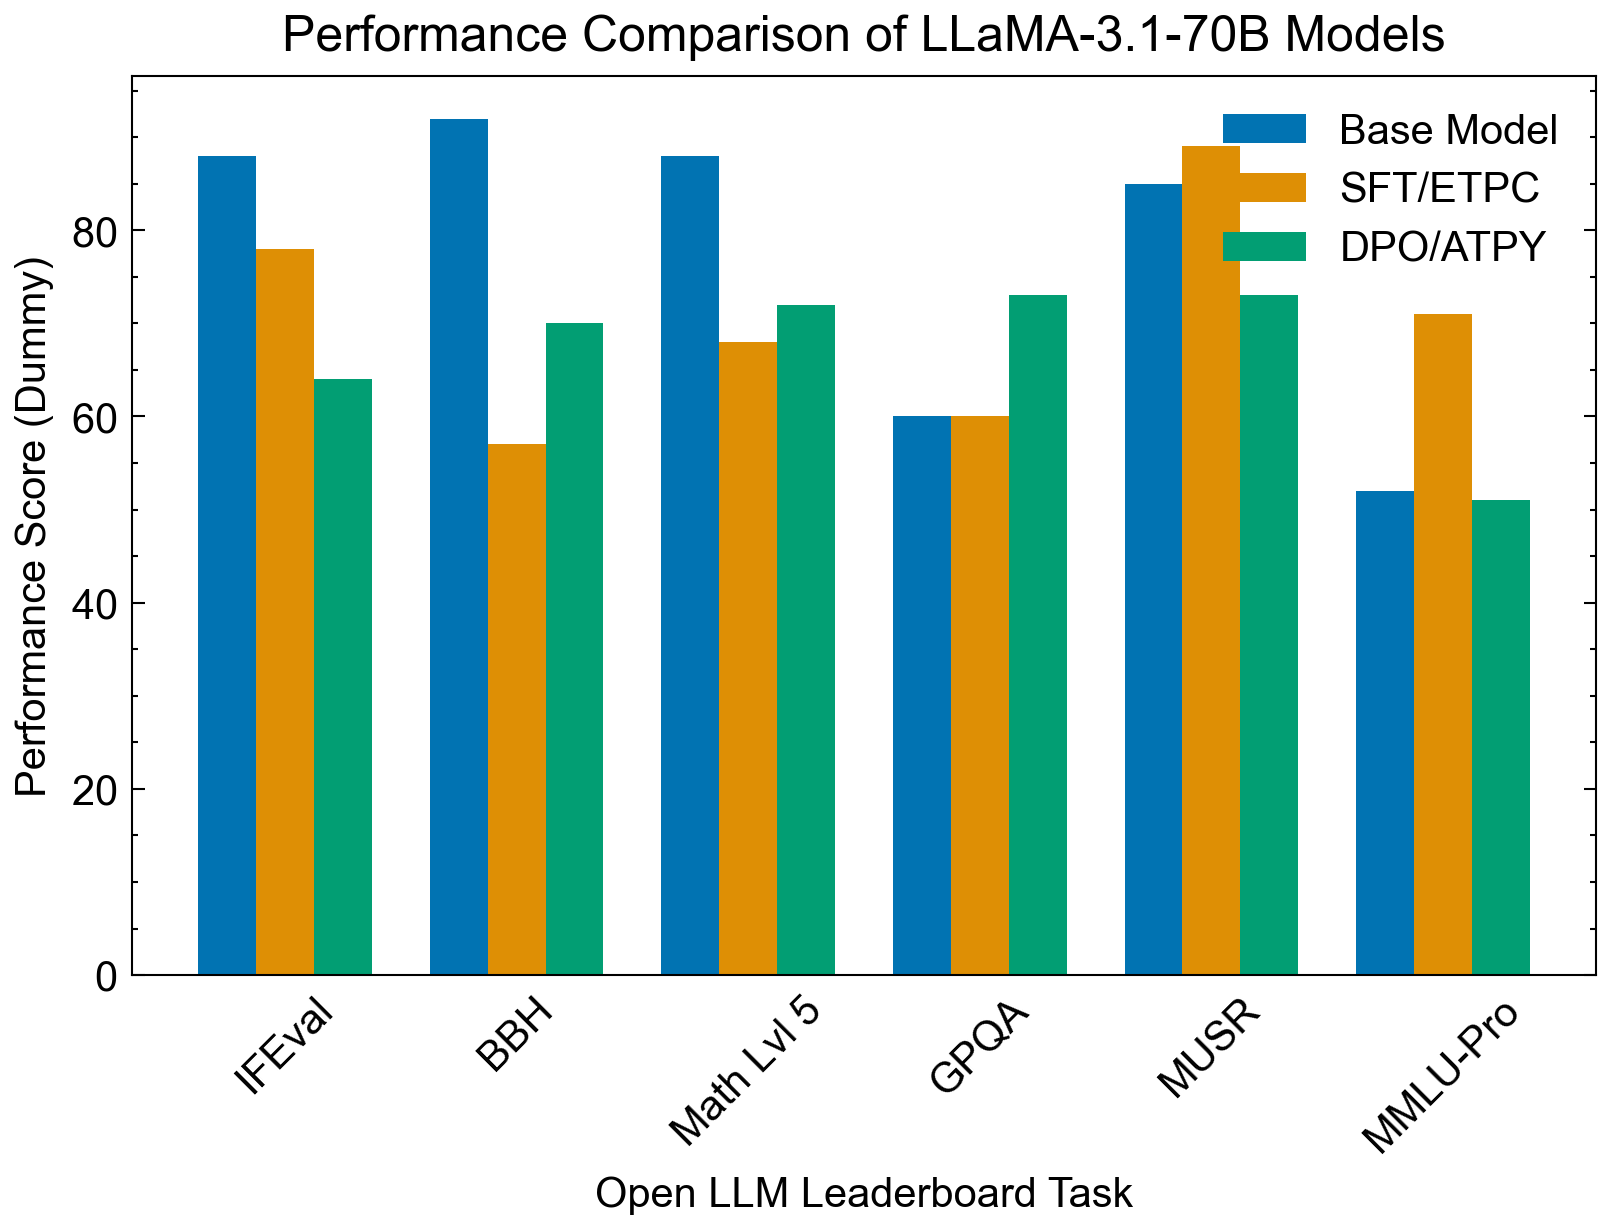

In [7]:
# Define tasks and models
tasks = ['IFEval', 'BBH', 'Math Lvl 5', 'GPQA', 'MUSR', 'MMLU-Pro']
models = ['Base Model', 'SFT/ETPC', 'DPO/ATPY']

# Create dummy scores for each task and model
np.random.seed(42)
scores = np.random.randint(50, 100, size=(len(tasks), len(models)))

# Create a grouped bar chart
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
bar_width = 0.25
index = np.arange(len(tasks))

# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(index + i * bar_width, scores[:, i], bar_width, label=model)

# Set labels, title, and ticks
ax.set_xlabel('Open LLM Leaderboard Task', fontsize=10)
ax.set_ylabel('Performance Score (Dummy)', fontsize=10)
ax.set_title('Performance Comparison of LLaMA-3.1-70B Models', fontsize=12)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(tasks)

# Add legend
ax.legend(fontsize=10)

# Rotate task labels for readability
plt.xticks(rotation=45)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

output_path = os.path.join(output_dir, "llmboard.pdf")
plt.savefig(output_path, dpi=300)

plt.show()


## Correlation Between Automatic Metrics and Human Judgment

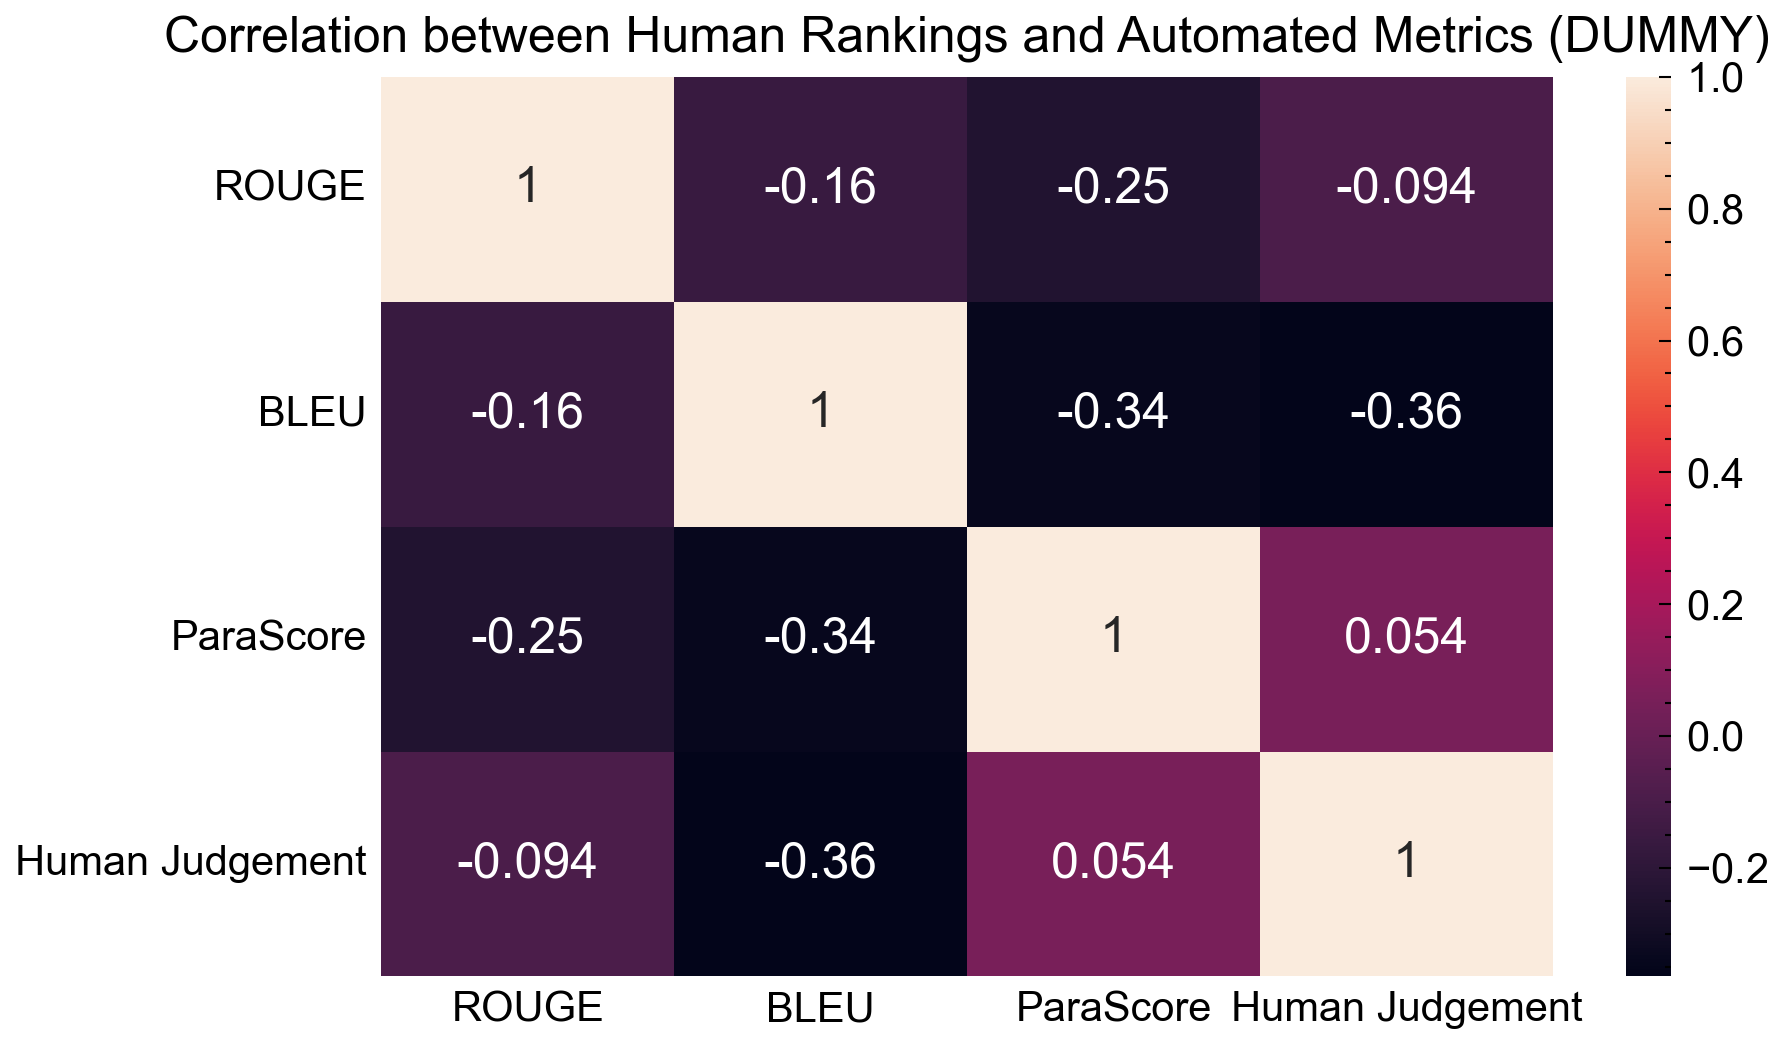

In [8]:
# Generate dummy scores for human rankings and automated metrics (ROUGE, BLEU, ParaScore)
rouge_scores = np.random.uniform(0.4, 0.9, size=10)  # ROUGE scores
bleu_scores = np.random.uniform(0.3, 0.8, size=10)  # BLEU scores
parascale_scores = np.random.uniform(0.5, 0.95, size=10)  # ParaScore
human_scores = np.random.uniform(0.5, 0.95, size=10) 

# Create a DataFrame for correlation matrix
data = {
    'ROUGE': rouge_scores,
    'BLEU': bleu_scores,
    'ParaScore': parascale_scores,
    'Human Judgement': human_scores
}
df = pd.DataFrame(data)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set figure size according to the provided description


# Create a heatmap for the correlation matrix
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
sns.heatmap(corr_matrix, annot=True, ax=ax, annot_kws={"fontsize": 12})

# Add title
plt.title('Correlation between Human Rankings and Automated Metrics (DUMMY)', fontsize=12)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis

# Save the correlation matrix as a PDF
output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()


## New metric

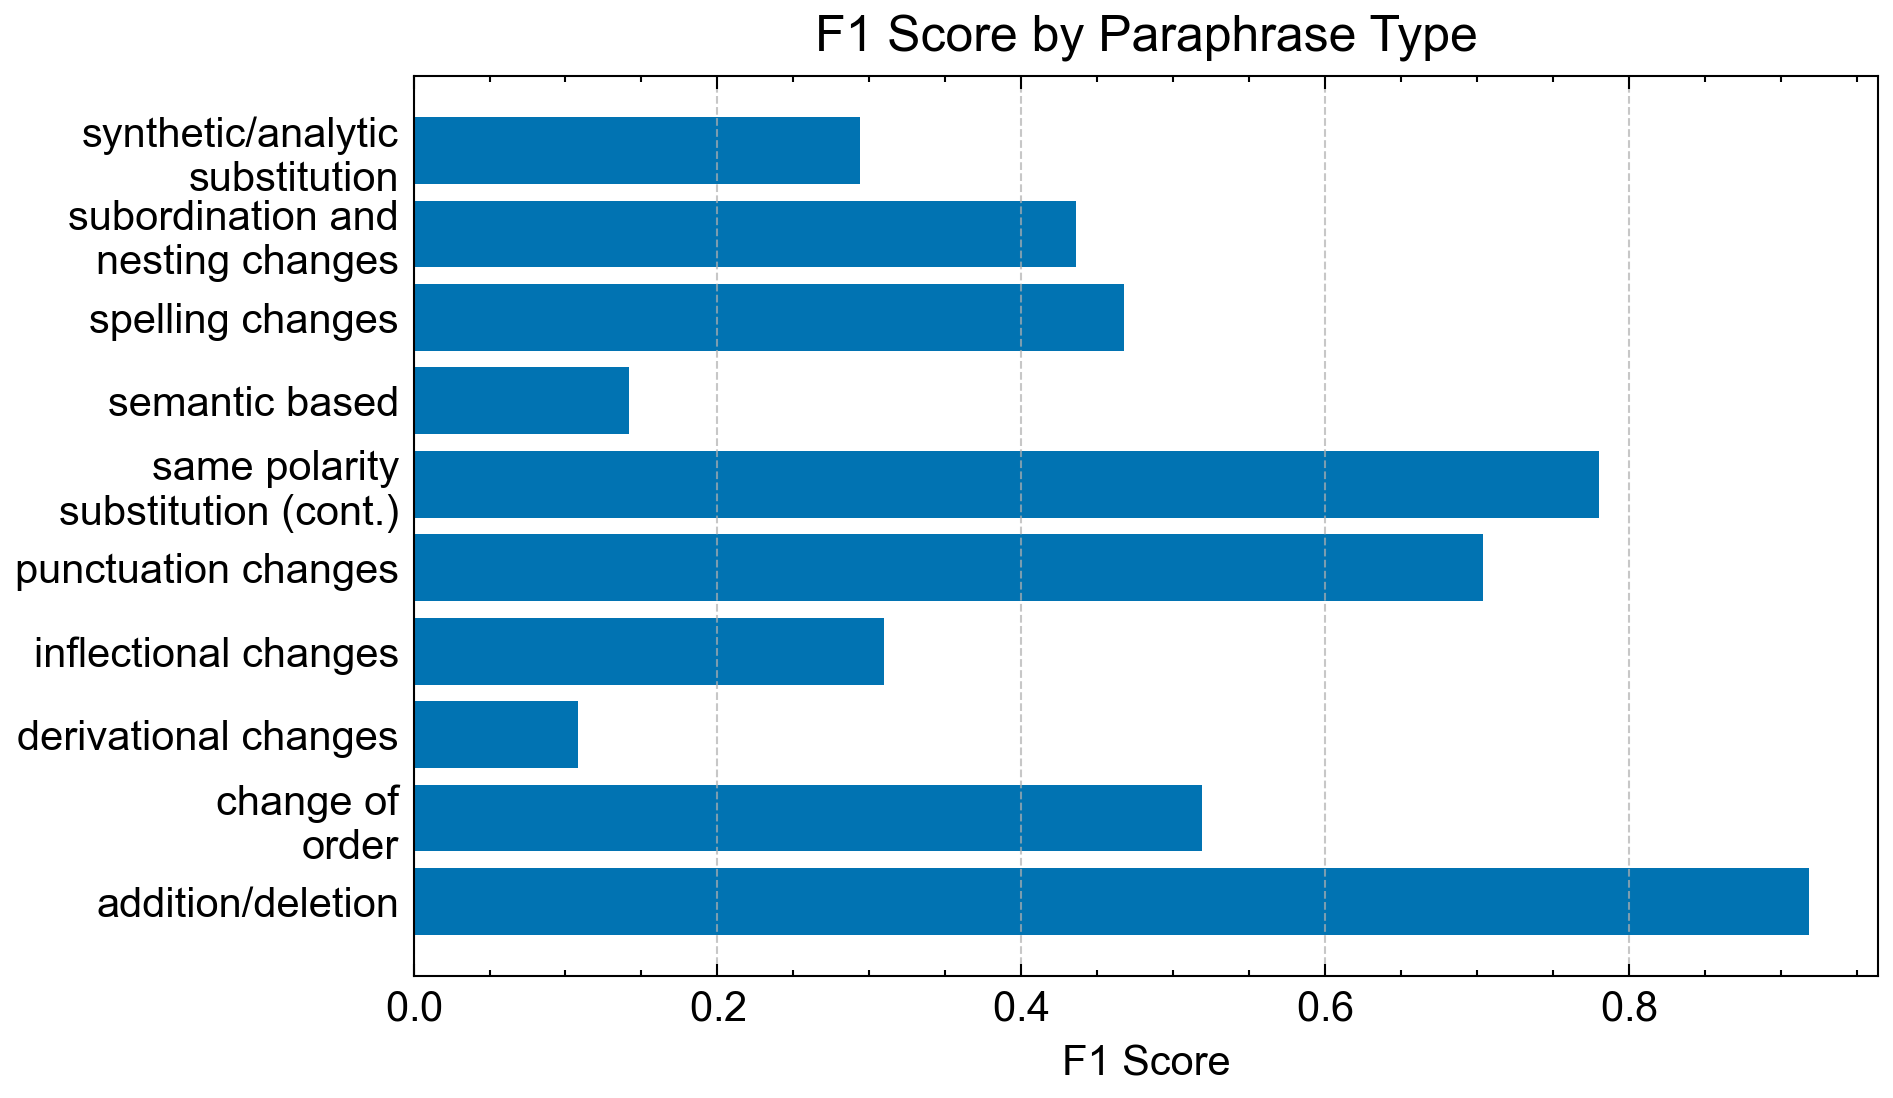

In [10]:
classification_data = pd.read_csv('/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_ptd_results_hyperclass_20241023_144857.csv', skiprows=13)

def add_line_breaks(text, n=2):
    # Add a custom line break for "synthetic/analytic substitution"
    if text == "synthetic/analytic substitution":
        return "synthetic/analytic\nsubstitution"
    if text == "same polarity substitution (contextual)":
        return "same polarity\nsubstitution (cont.)"
    
    # Otherwise, split the text into words and add line breaks every `n` words
    words = text.split(' ')
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

classification_data['Paraphrase Type'] = classification_data['Paraphrase Type'].apply(lambda x: add_line_breaks(x, n=2))

# Extract F1 scores for each paraphrase type, excluding rows like 'micro avg', 'macro avg', etc.
paraphrase_f1_scores = classification_data[~classification_data['Paraphrase Type'].str.contains('avg')]

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.barh(paraphrase_f1_scores['Paraphrase Type'], paraphrase_f1_scores['F1-score'])
plt.xlabel('F1 Score')
plt.title('F1 Score by Paraphrase Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)

ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis
output_path = os.path.join(output_dir, "new_type_score.pdf")
plt.savefig(output_path, dpi=300)

plt.show()


In [49]:

class ParaphraseTypeEvaluator:
    def __init__(self, model_name: str, top_k: int = 10):
        self.model_name = model_name
        self.top_k = top_k
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, local_files_only=True)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, clean_up_tokenization_spaces=True)
        self.model.eval()
        self.normalized_top_10_types = [ptype.strip().lower() for ptype in TOP_10_PARAPHRASE_TYPES]

    def preprocess_apt(self, apt: str) -> List[str]:
        apt_types = apt.lower().split(", ")
        filtered_types = [
            ptype.strip() for ptype in apt_types if ptype.strip() in self.normalized_top_10_types
        ]
        return filtered_types

    def extract_paraphrase(self, paraphrase_list: List[str]) -> str:
        """Extracts the actual paraphrase text from the given list entry."""
        # Ensure the list has the expected structure and process the second element.
        if len(paraphrase_list) >= 2:
            paraphrase_entry = paraphrase_list[1]
            # Extract text after 'Generated Paraphrase:' and clean it up.
            match = re.search(r"Generated Paraphrase:(.*)", paraphrase_entry, re.IGNORECASE)
            if match:
                # Extract everything after 'Generated Paraphrase:'
                cleaned_paraphrase = match.group(1).strip()
                
                # If there are multiple numbered paraphrases, extract only the first one.
                # Look for "1." and "2."
                numbered_match = re.search(r"1\.\s*(.*?)(?=\s*2\.)", cleaned_paraphrase, re.DOTALL)
                if numbered_match:
                    return numbered_match.group(1).strip()
                
                return cleaned_paraphrase
        return ""

    def predict_paraphrase_types(self, reference: str, paraphrase: str) -> List[str]:
        inputs = self.tokenizer(reference, paraphrase, truncation=True, max_length=256, return_tensors="pt")
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        
        top_k_indices = np.argsort(probs)[-self.top_k:][::-1]  # Descending order
        predicted_types = [TOP_10_PARAPHRASE_TYPES[idx] for idx in top_k_indices if probs[idx] > 0.5]
        return predicted_types

    def evaluate(self, json_file_path: str) -> pd.DataFrame:
            with open(json_file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)
            
            model_scores = {}
            single_accuracies = {}
            type_accuracies = {ptype: {} for ptype in TOP_10_PARAPHRASE_TYPES}

            for entry in data:
                reference = entry["data"]["Original"]
                true_types = self.preprocess_apt(entry["data"]["APT"])
                model_name = entry["data"]["Kind"]
                
                # Extract and clean the paraphrase text from the list.
                paraphrase = self.extract_paraphrase(entry["data"]["Paraphrase"])
                true_labels = [1 if ptype in true_types else 0 for ptype in TOP_10_PARAPHRASE_TYPES]
                predicted_types = self.predict_paraphrase_types(reference, paraphrase)
                pred_labels = [1 if ptype in predicted_types else 0 for ptype in TOP_10_PARAPHRASE_TYPES]
                
                # Calculate F1 Score
                f1 = f1_score(true_labels, pred_labels, average="macro", zero_division=0)
                # Store F1 scores by model
                if model_name not in model_scores:
                    model_scores[model_name] = []
                model_scores[model_name].append(f1)

                # Calculate single accuracy: if any true type is in predicted types.
                correct_prediction = any(ptype in predicted_types for ptype in true_types)
                if model_name not in single_accuracies:
                    single_accuracies[model_name] = {"correct": 0, "total": 0}
                single_accuracies[model_name]["correct"] += int(correct_prediction)
                single_accuracies[model_name]["total"] += 1

                # Update type-specific accuracies.
                for ptype in TOP_10_PARAPHRASE_TYPES:
                    if model_name not in type_accuracies[ptype]:
                        type_accuracies[ptype][model_name] = {"correct": 0, "total": 0}
                    if ptype in true_types:
                        type_accuracies[ptype][model_name]["total"] += 1
                        if ptype in predicted_types:
                            type_accuracies[ptype][model_name]["correct"] += 1

            # Calculate the average F1 score for each model
            avg_model_scores = {
                model: np.mean(scores) for model, scores in model_scores.items()
            }

            # Calculate single accuracy for each model
            model_single_accuracies = {
                model: (counts["correct"] / counts["total"]) * 100 if counts["total"] > 0 else 0
                for model, counts in single_accuracies.items()
            }

            # Calculate type-specific accuracy for each model and paraphrase type
            model_type_accuracies = {
                ptype: {
                    model: (counts["correct"] / counts["total"]) * 100 if counts["total"] > 0 else 0
                    for model, counts in type_accuracies[ptype].items()
                }
                for ptype in TOP_10_PARAPHRASE_TYPES
            }

            # Create a DataFrame from the scores, including the type-specific accuracies
            df_data = []
            for model in avg_model_scores:
                row = {
                    "Model": model,
                    "Average F1 Score": avg_model_scores[model],
                    "Single Accuracy": model_single_accuracies[model]
                }
                # Add each paraphrase type's accuracy to the row
                for ptype in TOP_10_PARAPHRASE_TYPES:
                    row[f"{ptype} accuracy"] = model_type_accuracies[ptype].get(model, 0)
                df_data.append(row)

            # Convert to DataFrame
            df = pd.DataFrame(df_data)
            
            return df


evaluator = ParaphraseTypeEvaluator(model_name="out/cls-models/deberta-base_qqp_pd_etpc_ptd/run-7/checkpoint-378")
df_results = evaluator.evaluate(json_file_path="/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json")


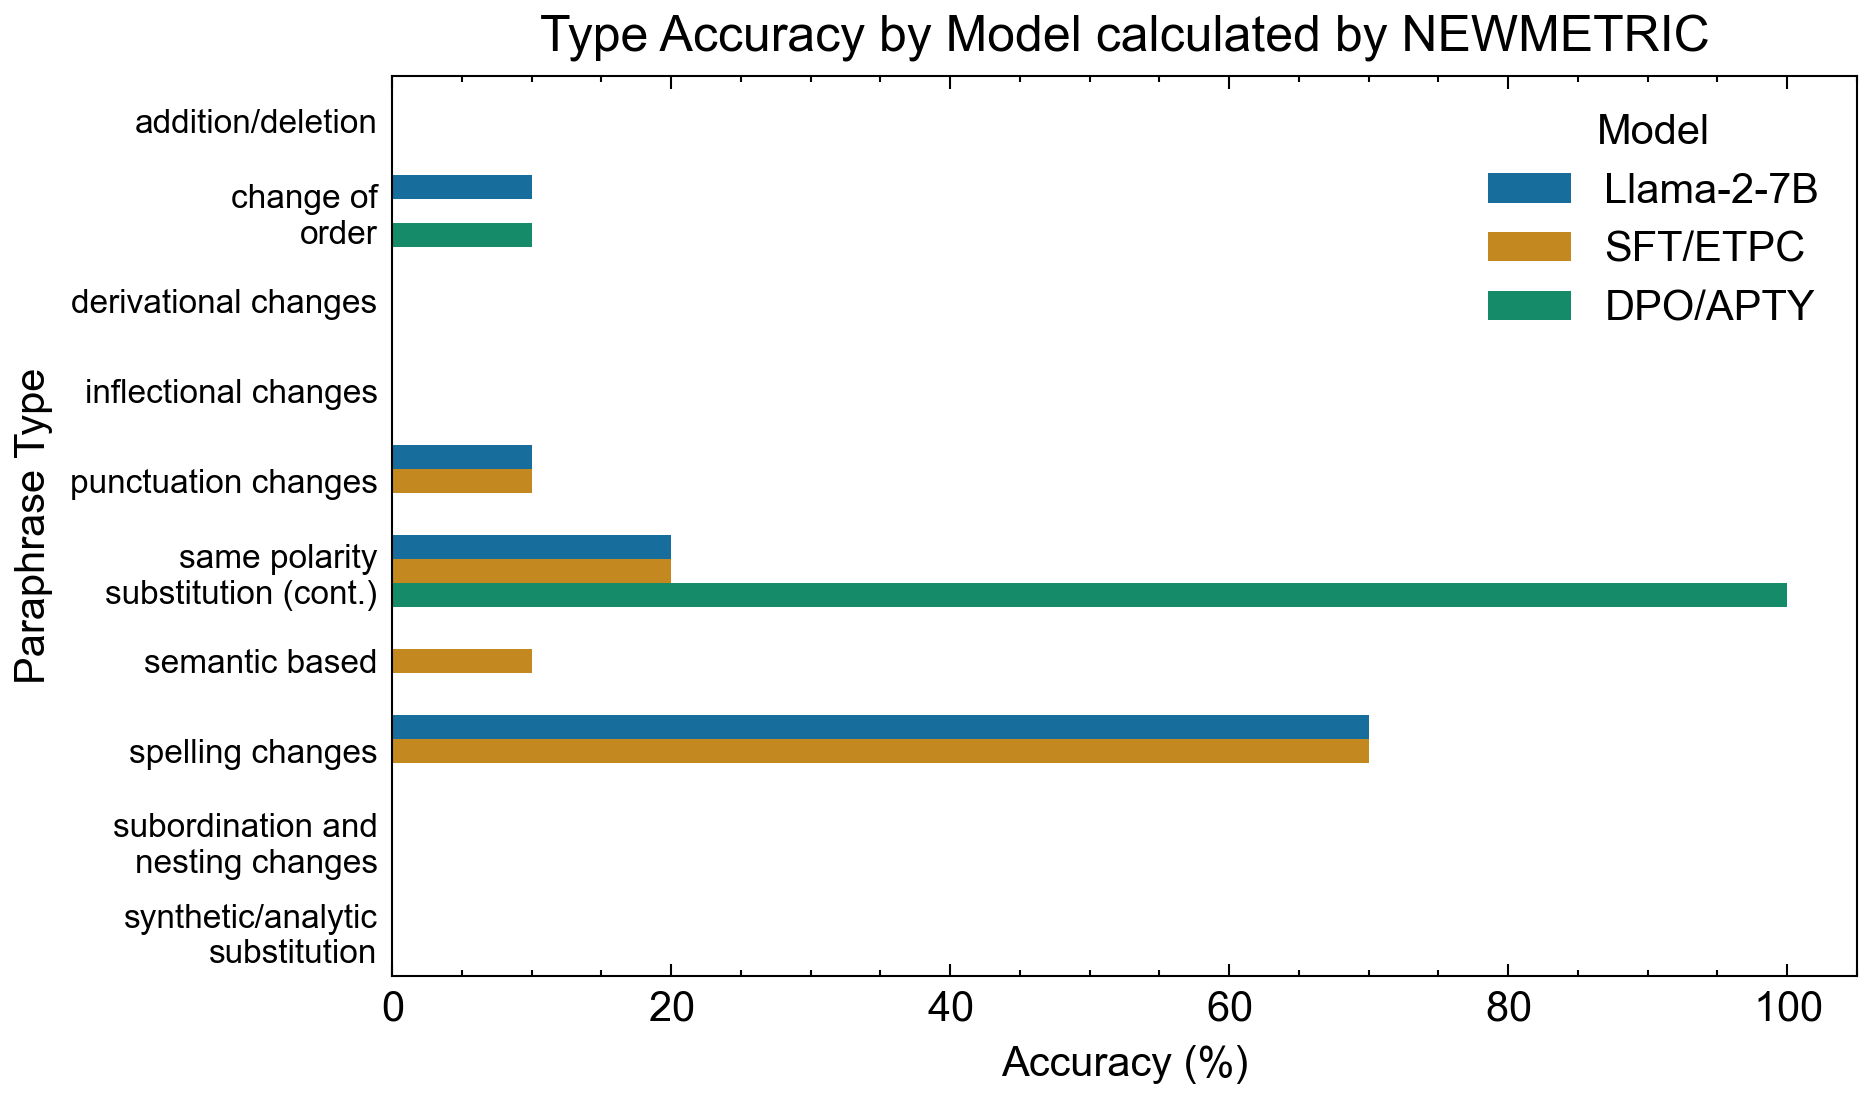

In [50]:
# Melt the DataFrame to have a suitable format for plotting
df_melted = df_results.melt(
    id_vars=['Model'],
    value_vars=[f"{ptype} accuracy" for ptype in TOP_10_PARAPHRASE_TYPES],
    var_name='Paraphrase Type',
    value_name='Accuracy'
)
df_melted['Paraphrase Type'] = df_melted['Paraphrase Type'].str.replace(" accuracy", "")

def add_line_breaks(text, n=2):
    # Add a custom line break for "synthetic/analytic substitution"
    if text == "synthetic/analytic substitution":
        return "synthetic/analytic\nsubstitution"
    if text == "same polarity substitution (contextual)":
        return "same polarity\nsubstitution (cont.)"
    
    # Otherwise, split the text into words and add line breaks every `n` words
    words = text.split(' ')
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

df_melted['Paraphrase Type'] = df_melted['Paraphrase Type'].apply(lambda x: add_line_breaks(x, n=2))


# Define the mapping for model names
model_rename_mapping = {
    "base_model": "Llama-2-7B",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY"
}

# Rename the models in the 'Model' column using the mapping
df_melted['Model'] = df_melted['Model'].replace(model_rename_mapping)

# Create a bar plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Create the bar plot with updated model names
sns.barplot(
    data=df_melted,
    y='Paraphrase Type',
    x='Accuracy',
    hue='Model'
)

# Customize the plot
plt.title('Type Accuracy by Model calculated by NEWMETRIC')
plt.ylabel('Paraphrase Type')
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis
plt.xlabel('Accuracy (%)')
plt.legend(title='Model') 
plt.yticks(fontsize=8)  # Adjust the size as needed

output_path = os.path.join(output_dir, "new_types.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

